In [1]:
from google.colab import files
uploaded = files.upload()

Saving wisc_bc_data.csv to wisc_bc_data.csv


Dataset Shape: (569, 32)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0  87139402         B        12.32         12.39           78.85      464.1   
1   8910251         B        10.60         18.95           69.28      346.4   
2    905520         B        11.04         16.83           70.92      373.2   
3    868871         B        11.28         13.39           73.00      384.8   
4   9012568         B        15.19         13.21           97.65      711.8   

   smoothness_mean  compactness_mean  concavity_mean  points_mean  ...  \
0          0.10280           0.06981         0.03987      0.03700  ...   
1          0.09688           0.11470         0.06387      0.02642  ...   
2          0.10770           0.07804         0.03046      0.02480  ...   
3          0.11640           0.11360         0.04635      0.04796  ...   
4          0.07963           0.06934         0.03393      0.02657  ...   

   radius_worst  texture_worst  perimeter_worst  area_w

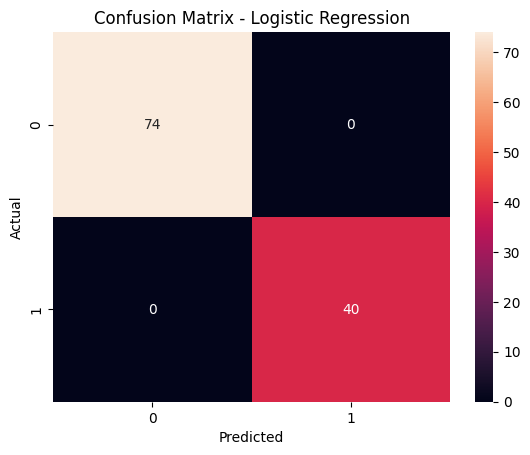


Cross-validation scores: [0.93859649 0.97368421 0.98245614 0.97368421 1.        ]
Mean CV Accuracy: 0.9736842105263157


In [ ]:
# =========================
# Breast Cancer Detection - Single Model (Logistic Regression)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# -------------------------
# Step 1: Load Dataset
# -------------------------
df = pd.read_csv('wisc_bc_data.csv')

print("Dataset Shape:", df.shape)
print(df.head())

# -------------------------
# Step 2: Data Preprocessing
# -------------------------
df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # M=1, B=0

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -------------------------
# Step 3: Train Model
# -------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# -------------------------
# Step 4: Evaluation
# -------------------------
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance:\n")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

# -------------------------
# Step 5: Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------
# Step 6: Cross Validation
# -------------------------
cv_scores = cross_val_score(model, X_scaled, y, cv=5)

print("\nCross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())